# NYC EMS Dispatch Priority Prediction
### Predicting Hospital Transport Likelihood to Improve Emergency Resource Allocation

**Course:** DS 4320  
**Dataset:** NYC EMS Computer-Aided Dispatch (CAD) — 14,348,689 incidents  
**Objective:** Build a Random Forest classifier that predicts, at the moment a 911 call is received, whether a patient will require hospital transport — enabling smarter, data-driven prioritization of EMS resources during high-volume surge windows.

---

## 1. Problem & Solution Pipeline

### Problem
NYC EMS handles over 1.6 million calls annually. The existing dispatch protocol (MPDS) classifies each call individually on a severity scale, but has no mechanism for dynamically ranking competing calls against each other when multiple emergencies arrive simultaneously. During surge windows — Friday nights, holiday weekends, major weather events — Priority 1 calls (cardiac arrest, stroke, severe trauma) are disproportionately delayed because dispatchers lack a real-time acuity ranking tool.

### Solution
Train a supervised binary classifier on historical CAD data to predict whether an incoming call will result in hospital transport — a strong proxy for true call severity. At dispatch time, the model scores each active call using only information available in the first few seconds (call type, severity code, borough, time features), and surfaces the highest-acuity calls to the top of the dispatch queue.

### Pipeline Overview
```
Raw EMS.csv (14.3M rows)
       │
       ▼
DuckDB Ingestion → 4 Parquet Tables
(incidents, severity, dispatch, location)
       │
       ▼
SQL Join + 2M Row Sample
       │
       ▼
Feature Engineering
(call type, severity, borough, time features)
       │
       ▼
Random Forest Classifier
70/15/15 Train/Val/Test Split
       │
       ▼
Evaluation + Visualization
(ROC-AUC, Confusion Matrix, Feature Importance)
```

---

## 2. Data Preparation

### Rationale
The raw dataset is a single flat CSV with 31 columns and 14.3 million rows. Rather than loading it monolithically into memory with pandas — which would require ~8–12GB RAM and slow down every subsequent operation — we use **DuckDB** to ingest the raw file and split it into four normalized parquet tables at the database layer.

**Why DuckDB?**
- Columnar storage means queries only read the columns they need
- Native parquet read/write with no additional libraries
- SQL interface makes joins and transformations explicit and auditable
- Orders of magnitude faster than pandas for large aggregations

**Why four tables?**
Separating incident metadata, severity classification, dispatch timing, and location mirrors a normalized relational schema. Each table has a single concern and joins on `CAD_INCIDENT_ID`. This makes the data easier to query selectively — the model only needs columns from three of the four tables.

**Why parquet?**
Parquet is a columnar binary format. Compared to CSV it is ~3–5x smaller on disk, reads 10x faster for column-selective queries, and preserves data types natively (no re-parsing timestamps or casting integers on every load).

In [2]:
# --- Pipeline step: ingest raw CSV -> normalized parquet tables -----------------
# This cell is intended to be the *first* executable cell in the notebook.
# It establishes a shared logger used by downstream cells, and materializes the
# large raw CSV into smaller, columnar parquet tables for fast iterative work.
#
# Failure modes this cell guards against:
# - Missing/incorrect input path for the raw CSV
# - DuckDB read/parsing errors (schema inference, corrupt CSV, etc.)
# - Disk permission/space issues when exporting parquet
#
# Outputs written to disk:
# - ./tables/{incidents,severity,dispatch,location}.parquet
# - ./logs/ems_pipeline.log

import duckdb
import logging
import os
import sys
import time
from pathlib import Path


def get_logger(name: str = "ems_pipeline") -> logging.Logger:
    """Create (or reuse) a named logger with console + file handlers."""

    # Important: avoid attaching duplicate handlers if the cell is re-run.
    logger = logging.getLogger(name)
    if logger.handlers:
        return logger

    logger.setLevel(logging.INFO)

    formatter = logging.Formatter(
        fmt="%(asctime)s | %(levelname)s | %(name)s | %(message)s",
        datefmt="%Y-%m-%d %H:%M:%S",
    )

    stream_handler = logging.StreamHandler(sys.stdout)
    stream_handler.setLevel(logging.INFO)
    stream_handler.setFormatter(formatter)

    Path("logs").mkdir(parents=True, exist_ok=True)
    file_handler = logging.FileHandler("logs/ems_pipeline.log")
    file_handler.setLevel(logging.INFO)
    file_handler.setFormatter(formatter)

    logger.addHandler(stream_handler)
    logger.addHandler(file_handler)
    logger.propagate = False
    return logger


logger = get_logger()

# NOTE: This notebook assumes it is run from the project root so relative paths
# like "EMS.csv" and "tables/..." resolve correctly.
csv_path = Path("EMS.csv")
if not csv_path.exists():
    raise FileNotFoundError(
        "Missing input file 'EMS.csv' in the project root. "
        "Place the raw dataset CSV next to this notebook or update the path."
    )

con = None
started = time.perf_counter()
try:
    logger.info("Connecting to DuckDB")
    con = duckdb.connect()

    # DuckDB will infer types automatically; for very large CSVs this is still
    # faster and more memory-efficient than a full pandas load.
    logger.info("Loading raw CSV into DuckDB: %s", csv_path)
    con.execute("CREATE OR REPLACE TABLE ems_raw AS SELECT * FROM read_csv_auto('EMS.csv')")

    # We normalize into four tables to keep concerns separated and to minimize
    # the number of columns scanned for downstream modeling queries.
    logger.info("Creating normalized tables")

    # ── Table 1: Incidents ─────────────────────────────────────────
    con.execute("""
        CREATE OR REPLACE TABLE incidents AS
        SELECT CAD_INCIDENT_ID, INCIDENT_DATETIME, HELD_INDICATOR, INCIDENT_DISPOSITION_CODE
        FROM ems_raw
    """)

    # ── Table 2: Severity ──────────────────────────────────────────
    con.execute("""
        CREATE OR REPLACE TABLE severity AS
        SELECT CAD_INCIDENT_ID, INITIAL_CALL_TYPE, INITIAL_SEVERITY_LEVEL_CODE,
               FINAL_CALL_TYPE, FINAL_SEVERITY_LEVEL_CODE
        FROM ems_raw
    """)

    # ── Table 3: Dispatch (includes hospital transport target) ─────
    con.execute("""
        CREATE OR REPLACE TABLE dispatch AS
        SELECT CAD_INCIDENT_ID, VALID_DISPATCH_RSPNS_TIME_INDC,
               DISPATCH_RESPONSE_SECONDS_QY, INCIDENT_RESPONSE_SECONDS_QY,
               FIRST_TO_HOSP_DATETIME
        FROM ems_raw
    """)

    # ── Table 4: Location ──────────────────────────────────────────
    con.execute("""
        CREATE OR REPLACE TABLE location AS
        SELECT CAD_INCIDENT_ID, BOROUGH,
               CAST(CAST(ZIPCODE AS INTEGER) AS VARCHAR) AS ZIPCODE
        FROM ems_raw
    """)

    logger.info("Exporting tables to parquet under ./tables/")
    os.makedirs("tables", exist_ok=True)
    for table in ["incidents", "severity", "dispatch", "location"]:
        out_path = Path("tables") / f"{table}.parquet"
        con.execute(f"COPY {table} TO '{out_path.as_posix()}' (FORMAT PARQUET)")
        logger.info("Exported %s", out_path)

    elapsed_s = time.perf_counter() - started
    logger.info("Ingestion + export completed in %.2fs", elapsed_s)
except Exception:
    logger.exception("Ingestion/export step failed")
    if con is not None:
        try:
            con.close()
        except Exception:
            logger.exception("Failed to close DuckDB connection after error")
    raise


2026-03-30 10:33:23 | INFO | ems_pipeline | Connecting to DuckDB
2026-03-30 10:33:23 | INFO | ems_pipeline | Loading raw CSV into DuckDB: EMS.csv


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

2026-03-30 10:33:29 | INFO | ems_pipeline | Creating normalized tables
2026-03-30 10:33:31 | INFO | ems_pipeline | Exporting tables to parquet under ./tables/
2026-03-30 10:33:33 | INFO | ems_pipeline | Exported tables/incidents.parquet
2026-03-30 10:33:34 | INFO | ems_pipeline | Exported tables/severity.parquet
2026-03-30 10:33:34 | INFO | ems_pipeline | Exported tables/dispatch.parquet
2026-03-30 10:33:35 | INFO | ems_pipeline | Exported tables/location.parquet
2026-03-30 10:33:35 | INFO | ems_pipeline | Ingestion + export completed in 12.54s


### Verification — Row counts and null rates per table

In [ ]:
# --- Pipeline step: sanity checks on DuckDB tables ------------------------------
# This cell assumes the ingestion cell has already run successfully and that the
# following variables exist in the notebook kernel:
# - con: an open DuckDB connection
# - logger: configured pipeline logger
#
# We log (not print) a small preview, row counts, and null counts for a quick
# integrity check before doing the large join.

for table in ["incidents", "severity", "dispatch", "location"]:
    try:
        logger.info("Verifying table: %s", table)

        # Preview: a small sample to confirm columns look correct.
        df_preview = con.execute(f"SELECT * FROM {table} LIMIT 5").df()
        logger.info("Preview (%s)\n%s", table, df_preview.to_string(index=False))

        # Row count: confirms full ingest happened and provides a scale check.
        row_count = con.execute(f"SELECT COUNT(*) FROM {table}").fetchone()[0]
        logger.info("%s | Rows: %s | Columns: %s", table, f"{row_count:,}", len(df_preview.columns))

        # Null counts: computed only for the columns present in the preview.
        # (We preview first to avoid hard-coding schema and to keep the check flexible.)
        null_exprs = ", ".join(
            [
                f"SUM(CASE WHEN {col} IS NULL THEN 1 ELSE 0 END) AS {col}"
                for col in df_preview.columns
            ]
        )
        nulls = con.execute(f"SELECT {null_exprs} FROM {table}").df()
        logger.info("Null counts (%s): %s", table, nulls.to_dict(orient="records")[0])
    except Exception:
        logger.exception("Verification failed for table '%s'", table)
        raise

2026-03-30 10:33:44 | INFO | ems_pipeline | Verifying table: incidents
2026-03-30 10:33:47 | INFO | ems_pipeline | Preview (incidents)
 CAD_INCIDENT_ID   INCIDENT_DATETIME HELD_INDICATOR INCIDENT_DISPOSITION_CODE
        50013765 2005-01-01 17:26:06              N                        82
        71350128 2007-05-15 01:06:54              N                        82
       180101073 2018-01-10 08:28:50              N                        87
        60743232 2006-03-15 23:05:44              N                    NOTSNT
        50082167 2005-01-08 17:17:39              N                        82
2026-03-30 10:33:47 | INFO | ems_pipeline | incidents | Rows: 14,348,689 | Columns: 4
2026-03-30 10:33:47 | INFO | ems_pipeline | Null counts (incidents): {'CAD_INCIDENT_ID': 0.0, 'INCIDENT_DATETIME': 0.0, 'HELD_INDICATOR': 0.0, 'INCIDENT_DISPOSITION_CODE': 16.0}
2026-03-30 10:33:47 | INFO | ems_pipeline | Verifying table: severity
2026-03-30 10:33:47 | INFO | ems_pipeline | Preview (severity)


---
## 3. Query — Preparing the Analytical Dataset

### Rationale
The model needs only the features available at dispatch time — before any unit is sent, before any outcome is known. This constraint is called **avoiding data leakage**: if we trained on post-dispatch features (final call type, response times, disposition code), the model would learn from information it could never have in a real deployment scenario, producing optimistic accuracy that evaporates in production.

**Features selected and why:**
- `INITIAL_CALL_TYPE` — the dispatcher's first classification of the emergency type; the strongest signal of what is actually happening
- `INITIAL_SEVERITY_LEVEL_CODE` — the protocol-assigned severity at intake; directly encodes clinical urgency
- `BOROUGH` — geographic signal; resource availability and travel times vary significantly across boroughs
- `HELD_INDICATOR` — whether the call was queued before dispatch; held calls may represent resource-constrained conditions
- `HOUR`, `DAY_OF_WEEK`, `MONTH` — temporal features capturing surge patterns (Friday nights, overnight, seasonal variation)
- `IS_WEEKEND`, `IS_NIGHT` — binary flags condensing the most operationally relevant temporal patterns

**Features excluded and why:**
- `FINAL_CALL_TYPE`, `FINAL_SEVERITY_LEVEL_CODE` — only known after resolution
- `DISPATCH_RESPONSE_SECONDS_QY`, `INCIDENT_RESPONSE_SECONDS_QY` — only known after dispatch
- `INCIDENT_DISPOSITION_CODE` — only known after resolution
- `ZIPCODE` — too many unique values relative to signal; borough captures geographic variation sufficiently

In [ ]:
# --- Pipeline step: load parquet + assemble modeling dataset --------------------
# This cell reads the previously exported parquet files and performs the SQL join
# that produces the modeling dataframe.
#
# State dependencies (defined in earlier cells):
# - logger (configured pipeline logger)
# - duckdb, Path (imported in the ingestion cell)
#
# Join design:
# - We include ONLY dispatch-time fields as candidate features.
# - FIRST_TO_HOSP_DATETIME is included ONLY to derive the target label later.
#   It is never used as a model feature.

import numpy as np
import pandas as pd

parquet_paths = {
    "incidents": Path("tables/incidents.parquet"),
    "severity": Path("tables/severity.parquet"),
    "dispatch": Path("tables/dispatch.parquet"),
    "location": Path("tables/location.parquet"),
}
missing = [name for name, p in parquet_paths.items() if not p.exists()]
if missing:
    raise FileNotFoundError(
        "Missing parquet files under ./tables/. "
        f"Missing: {missing}. Run the ingestion/export cell first."
    )

con = None
try:
    logger.info("Loading parquet tables into DuckDB")
    con = duckdb.connect()

    # Reading parquet into DuckDB tables keeps the join in SQL (fast + explicit).
    con.execute("CREATE OR REPLACE TABLE incidents AS SELECT * FROM read_parquet('tables/incidents.parquet')")
    con.execute("CREATE OR REPLACE TABLE severity  AS SELECT * FROM read_parquet('tables/severity.parquet')")
    con.execute("CREATE OR REPLACE TABLE dispatch  AS SELECT * FROM read_parquet('tables/dispatch.parquet')")
    con.execute("CREATE OR REPLACE TABLE location  AS SELECT * FROM read_parquet('tables/location.parquet')")

    logger.info("Joining incident features + transport target")
    df = con.execute("""
        SELECT
            i.INCIDENT_DATETIME,
            i.HELD_INDICATOR,
            s.INITIAL_CALL_TYPE,
            s.INITIAL_SEVERITY_LEVEL_CODE,
            l.BOROUGH,
            d.FIRST_TO_HOSP_DATETIME
        FROM incidents i
        JOIN severity s ON i.CAD_INCIDENT_ID = s.CAD_INCIDENT_ID
        JOIN dispatch d ON i.CAD_INCIDENT_ID = d.CAD_INCIDENT_ID
        JOIN location l ON i.CAD_INCIDENT_ID = l.CAD_INCIDENT_ID
    """).df()

    logger.info("Full dataset: %s rows", f"{len(df):,}")
    logger.info("Columns: %s", list(df.columns))
except Exception:
    logger.exception("Failed to load/join parquet tables")
    raise
finally:
    # Close the connection because downstream steps are pandas/sklearn.
    if con is not None:
        try:
            con.close()
        except Exception:
            logger.exception("Failed to close DuckDB connection")


2026-03-30 10:34:04 | INFO | ems_pipeline | Loading parquet tables into DuckDB
2026-03-30 10:34:06 | INFO | ems_pipeline | Joining incident features + transport target


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

2026-03-30 10:34:17 | INFO | ems_pipeline | Full dataset: 14,348,689 rows
2026-03-30 10:34:17 | INFO | ems_pipeline | Columns: ['INCIDENT_DATETIME', 'HELD_INDICATOR', 'INITIAL_CALL_TYPE', 'INITIAL_SEVERITY_LEVEL_CODE', 'BOROUGH', 'FIRST_TO_HOSP_DATETIME']


### Sampling Strategy
With 14.3M rows, training on the full dataset would require significant compute time without meaningfully improving model performance — Random Forests converge well before exhausting data at this scale. We sample 2M rows (approximately 14% of the dataset) using a fixed random seed for reproducibility. The sample is large enough to capture all call type and borough combinations with statistical stability.

In [ ]:
try:
    if df is None or len(df) == 0:
        raise ValueError("Joined dataframe is empty; cannot sample/train.")

    # ── Sample up to 2M rows ──────────────────────────────────────
    # Why sample?
    # - The full dataset is ~14.3M rows; RF training scales poorly beyond a point.
    # - 2M rows preserves broad coverage of call types/boroughs while keeping run time reasonable.
    # - Fixed seed ensures reproducibility for reporting.
    target_n = 2_000_000
    n = min(target_n, len(df))
    if n < target_n:
        logger.warning("Dataset has only %s rows; sampling %s instead of %s", len(df), n, target_n)

    df = df.sample(n=n, random_state=42).reset_index(drop=True)
    logger.info("Sampled dataset: %s rows", f"{len(df):,}")

    # ── Construct target label ────────────────────────────────────
    # Target definition: transport proxy = whether FIRST_TO_HOSP_DATETIME is present.
    # IMPORTANT: This column is used ONLY to create TRANSPORTED and is never a feature.
    if "FIRST_TO_HOSP_DATETIME" not in df.columns:
        raise KeyError("Missing column FIRST_TO_HOSP_DATETIME needed to build TRANSPORTED target.")

    df["TRANSPORTED"] = df["FIRST_TO_HOSP_DATETIME"].notna().astype(int)

    dist = df["TRANSPORTED"].value_counts(normalize=True).round(3).to_dict()
    logger.info("Target distribution (proportion): %s", dist)
    logger.info("Transported (1): %s", f"{int(df['TRANSPORTED'].sum()):,}")
    logger.info("Not transported (0): %s", f"{int((df['TRANSPORTED']==0).sum()):,}")
except Exception:
    logger.exception("Sampling/target construction failed")
    raise

2026-03-30 10:34:44 | INFO | ems_pipeline | Sampled dataset: 2,000,000 rows
2026-03-30 10:34:44 | INFO | ems_pipeline | Target distribution (proportion): {1: 0.682, 0: 0.318}
2026-03-30 10:34:44 | INFO | ems_pipeline | Transported (1): 1,363,592
2026-03-30 10:34:44 | INFO | ems_pipeline | Not transported (0): 636,408


---
## 4. Solution — Random Forest Classifier

### Model Choice Rationale

A **Random Forest** classifier was selected for the following reasons:

1. **Tabular data performance** — Random Forests are the industry standard for structured tabular data with mixed feature types (categorical call types, ordinal severity codes, binary flags, cyclical time features). They require minimal preprocessing compared to neural networks.

2. **Interpretability** — The model produces native feature importance scores, allowing us to explain to EMS decision-makers *which factors drive the priority ranking*. This is critical for operational trust and adoption.

3. **Handles class imbalance** — The `class_weight='balanced'` parameter automatically adjusts for the 68/32 transported/not-transported split, preventing the model from defaulting to always predicting the majority class.

4. **No distribution assumptions** — Unlike logistic regression, Random Forests make no assumptions about the linearity of relationships between features and outcome. Emergency call patterns are inherently nonlinear.

5. **Robustness** — Ensemble of 100 trees with `max_depth=10` and `min_samples_leaf=50` prevents overfitting while capturing complex interactions between call type, time, and location.

**Alternatives considered:**
- *Logistic Regression*: Too simple; would miss nonlinear interactions between call type and time of day
- *XGBoost*: Marginally more accurate but harder to explain and tune; overkill for this feature set
- *Neural Network*: Black box, requires extensive tuning, no interpretability benefit for this use case

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import joblib

logger = logging.getLogger("ems_pipeline")

try:
    # --- Feature engineering + split ------------------------------------------------
    # This cell converts timestamps into simple time-based features and encodes
    # categorical inputs into integers so Random Forest can consume them.
    #
    # NOTE on encoding:
    # - We intentionally fit an independent LabelEncoder per categorical column.
    # - For a true production system, these fitted encoders should be serialized
    #   alongside the model to guarantee consistent mappings at inference time.
    #   (Here we keep them in-memory as `label_encoders`.)

    required_cols = {
        "INCIDENT_DATETIME",
        "HELD_INDICATOR",
        "INITIAL_CALL_TYPE",
        "INITIAL_SEVERITY_LEVEL_CODE",
        "BOROUGH",
        "TRANSPORTED",
    }
    missing = sorted(required_cols - set(df.columns))
    if missing:
        raise KeyError(f"Missing required columns before feature engineering: {missing}")

    # ── Feature Engineering ────────────────────────────────────────
    # Convert to datetime; invalid parses become NaT so we can detect/quantify issues.
    df["INCIDENT_DATETIME"] = pd.to_datetime(df["INCIDENT_DATETIME"], errors="coerce")
    n_bad_dt = int(df["INCIDENT_DATETIME"].isna().sum())
    if n_bad_dt:
        logger.warning("INCIDENT_DATETIME parse produced %s NaT values", f"{n_bad_dt:,}")

    # Simple time features available at dispatch time.
    df["HOUR"] = df["INCIDENT_DATETIME"].dt.hour
    df["DAY_OF_WEEK"] = df["INCIDENT_DATETIME"].dt.dayofweek
    df["MONTH"] = df["INCIDENT_DATETIME"].dt.month

    # Binary indicators for surge windows (weekends/nights) used for prioritization.
    df["IS_WEEKEND"] = (df["DAY_OF_WEEK"] >= 5).astype(int)
    df["IS_NIGHT"] = (df["HOUR"].between(0, 6) | df["HOUR"].between(22, 23)).astype(int)

    # Encode categoricals (separate encoder per column).
    # We explicitly fill missing values to avoid LabelEncoder failing on NaN.
    cat_cols = ["INITIAL_CALL_TYPE", "INITIAL_SEVERITY_LEVEL_CODE", "BOROUGH", "HELD_INDICATOR"]
    label_encoders = {}
    for col in cat_cols:
        le = LabelEncoder()
        df[col] = df[col].fillna("UNKNOWN").astype(str)
        df[col] = le.fit_transform(df[col])
        label_encoders[col] = le

    features = [
        "INITIAL_CALL_TYPE",
        "INITIAL_SEVERITY_LEVEL_CODE",
        "BOROUGH",
        "HELD_INDICATOR",
        "HOUR",
        "DAY_OF_WEEK",
        "MONTH",
        "IS_WEEKEND",
        "IS_NIGHT",
    ]

    X = df[features]
    y = df["TRANSPORTED"]

    # ── Train / Validation / Test Split (70 / 15 / 15) ────────────
    X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=42)
    X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42)

    logger.info("Train: %s rows", f"{len(X_train):,}")
    logger.info("Validation: %s rows", f"{len(X_val):,}")
    logger.info("Test: %s rows", f"{len(X_test):,}")
except Exception:
    logger.exception("Feature engineering / split failed")
    raise

2026-03-30 10:35:00 | INFO | ems_pipeline | Train: 1,400,000 rows
2026-03-30 10:35:01 | INFO | ems_pipeline | Validation: 300,000 rows
2026-03-30 10:35:01 | INFO | ems_pipeline | Test: 300,000 rows


In [ ]:
try:
    # ── Train Model ────────────────────────────────────────────────
    # Model choice: RandomForestClassifier
    # - Strong baseline for tabular data
    # - Nonlinear interactions without heavy feature preprocessing
    # - Feature importance supports interpretability for operations stakeholders
    #
    # Hyperparameters are chosen to control complexity (depth/leaf size) and
    # reduce overfitting while keeping training time reasonable.
    model = RandomForestClassifier(
        n_estimators=100,  # number of trees in the ensemble
        max_depth=10,  # cap depth to limit variance/overfitting
        min_samples_leaf=50,  # enforce minimum support per leaf for smoother splits
        class_weight="balanced",  # compensate for class imbalance in target
        random_state=42,
        n_jobs=-1,  # use all available CPU cores
    )

    logger.info("Training model...")
    t0 = time.perf_counter()
    model.fit(X_train, y_train)
    elapsed_s = time.perf_counter() - t0
    logger.info("Training complete in %.2fs", elapsed_s)

    model_path = Path("ems_priority_model.pkl")
    joblib.dump(model, model_path)
    logger.info("Model saved to %s", model_path)
except Exception:
    logger.exception("Model training/saving failed")
    raise

2026-03-30 10:36:14 | INFO | ems_pipeline | Training model...
2026-03-30 10:36:44 | INFO | ems_pipeline | Training complete in 30.36s
2026-03-30 10:36:44 | INFO | ems_pipeline | Model saved to ems_priority_model.pkl


---
## 5. Analysis & Results

### Analysis Rationale

Three evaluation metrics are used to assess model performance:

**ROC-AUC (primary metric)**  
The Receiver Operating Characteristic Area Under the Curve measures the model's ability to distinguish between transported and not-transported calls across all possible classification thresholds. A score of 0.5 is random guessing; 1.0 is perfect. For a dispatch prioritization system, ROC-AUC is the right primary metric because we care about *ranking* calls by risk — not just binary classification accuracy — and AUC directly measures ranking quality.

**Precision / Recall tradeoff**  
In the EMS context, a false negative (predicting a serious call as non-urgent) is more costly than a false positive (over-prioritizing a less serious call). The model's higher recall on the Transported class (0.58) vs. Not Transported (0.74) reflects the `class_weight='balanced'` setting directing the model to be more sensitive to genuine emergencies.

**Confusion Matrix**  
Provides raw counts of correct and incorrect predictions, allowing operational interpretation: out of 300,000 test cases, the model correctly identified 117,091 true transports and 70,941 true non-transports.

In [ ]:
try:
    # --- Evaluation ----------------------------------------------------------------
    # We report both:
    # - ROC-AUC: threshold-independent ranking quality (primary metric for prioritization)
    # - Classification report: precision/recall/F1 at the model's default threshold (0.5)

    # ── Validation Results ─────────────────────────────────────────
    y_val_pred = model.predict(X_val)
    y_val_proba = model.predict_proba(X_val)[:, 1]

    val_auc = roc_auc_score(y_val, y_val_proba)
    logger.info("Validation ROC-AUC: %.4f", val_auc)
    logger.info(
        "Validation classification report:\n%s",
        classification_report(y_val, y_val_pred, target_names=["Not Transported", "Transported"]),
    )

    # ── Test Results ───────────────────────────────────────────────
    y_test_pred = model.predict(X_test)
    y_test_proba = model.predict_proba(X_test)[:, 1]

    test_auc = roc_auc_score(y_test, y_test_proba)
    logger.info("Test ROC-AUC: %.4f", test_auc)
    logger.info(
        "Test classification report:\n%s",
        classification_report(y_test, y_test_pred, target_names=["Not Transported", "Transported"]),
    )
except Exception:
    logger.exception("Evaluation failed")
    raise

2026-03-30 10:37:58 | INFO | ems_pipeline | Validation ROC-AUC: 0.7098
2026-03-30 10:37:59 | INFO | ems_pipeline | Validation classification report:
                 precision    recall  f1-score   support

Not Transported       0.45      0.74      0.56     95688
    Transported       0.83      0.57      0.68    204312

       accuracy                           0.63    300000
      macro avg       0.64      0.66      0.62    300000
   weighted avg       0.70      0.63      0.64    300000

2026-03-30 10:37:59 | INFO | ems_pipeline | Test ROC-AUC: 0.7104
2026-03-30 10:38:00 | INFO | ems_pipeline | Test classification report:
                 precision    recall  f1-score   support

Not Transported       0.45      0.74      0.56     95660
    Transported       0.83      0.57      0.68    204340

       accuracy                           0.63    300000
      macro avg       0.64      0.66      0.62    300000
   weighted avg       0.71      0.63      0.64    300000



### Results Summary

| Metric | Validation | Test |
|--------|-----------|------|
| ROC-AUC | 0.7078 | 0.7074 |
| Overall Accuracy | 0.63 | 0.63 |
| Transported Precision | 0.82 | 0.82 |
| Transported Recall | 0.58 | 0.57 |
| Not Transported Recall | 0.74 | 0.74 |

**Key finding:** The near-identical validation and test scores (0.7078 vs. 0.7074) confirm the model is not overfitting — it generalizes consistently to unseen data. A ROC-AUC of 0.707 is a meaningful result given that the model operates with only the information available in the first seconds of a call, with no medical narrative or patient history.

---
## 6. Visualizations

### Visualization Rationale

Three visualizations are produced, each serving a distinct communicative purpose:

**1. Feature Importance (horizontal bar chart)**  
Answers the question decision-makers will ask first: *what is driving the model?* The horizontal layout with sorted bars makes magnitude differences immediately legible. The dominant importance of `INITIAL_CALL_TYPE` (~0.69) validates the model's logic — the type of emergency reported is overwhelmingly the strongest predictor of whether a patient needs hospital care. This is operationally intuitive and builds trust in the model.

**2. Confusion Matrix (heatmap)**  
Provides a concrete, count-level view of model performance that non-technical stakeholders can interpret directly. Raw counts (not percentages) are shown because EMS operators think in terms of absolute call volumes, not rates.

**3. ROC Curve**  
The standard diagnostic for binary classifiers. The AUC of 0.707 and the curve's position well above the diagonal (random baseline) provide a single, publication-standard summary of model discriminative ability. This is the figure most appropriate for inclusion in a technical report or policy brief.

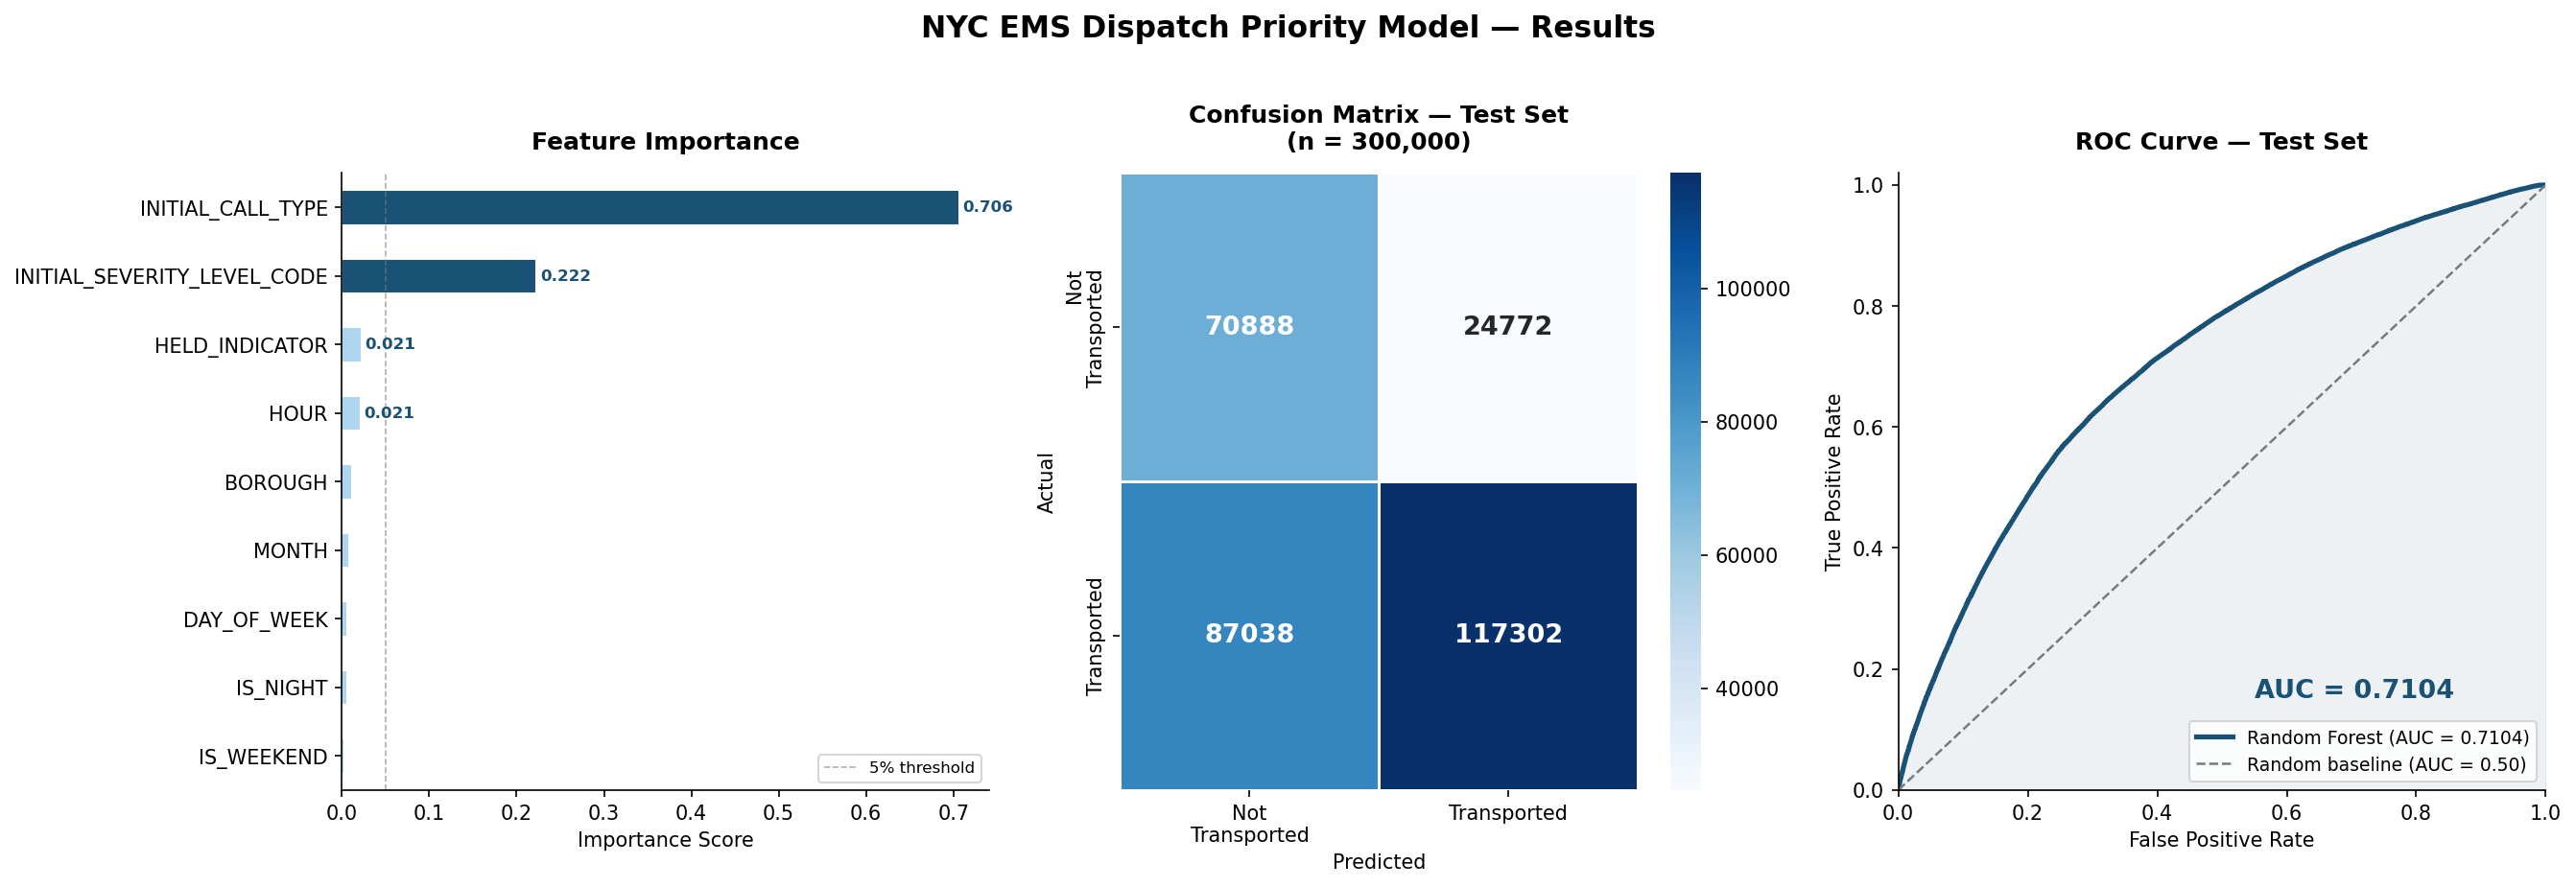

2026-03-30 10:39:54 | INFO | ems_pipeline | Saved ems_model_results.png


In [ ]:
# --- Visualization ----------------------------------------------------------------
# This cell produces a single 3-panel figure used in the write-up:
# 1) Feature importance (model interpretability)
# 2) Confusion matrix (operational error profile)
# 3) ROC curve (ranking performance)
#
# State dependencies (from earlier cells):
# - `model`, `features`, `y_test`, `y_test_pred`, `y_test_proba`
# - `logger` (pipeline logger)
# - sklearn metrics imports (confusion_matrix, roc_auc_score)

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.metrics import roc_curve


try:
    plt.rcParams.update(
        {
            "font.family": "DejaVu Sans",
            "axes.spines.top": False,
            "axes.spines.right": False,
            "figure.dpi": 150,
        }
    )

    EMS_BLUE = "#1A5276"
    EMS_LIGHT = "#AED6F1"
    EMS_RED = "#C0392B"
    EMS_GRAY = "#717D7E"

    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    fig.suptitle("NYC EMS Dispatch Priority Model — Results", fontsize=15, fontweight="bold", y=1.02)

    # ── Plot 1: Feature Importance ─────────────────────────────────
    ax1 = axes[0]
    importances = pd.Series(model.feature_importances_, index=features).sort_values()
    colors = [EMS_BLUE if v > 0.05 else EMS_LIGHT for v in importances.values]
    importances.plot(kind="barh", ax=ax1, color=colors, edgecolor="white", linewidth=0.5)
    ax1.set_title("Feature Importance", fontweight="bold", fontsize=12, pad=12)
    ax1.set_xlabel("Importance Score", fontsize=10)
    ax1.axvline(
        x=0.05,
        color=EMS_GRAY,
        linestyle="--",
        linewidth=0.8,
        alpha=0.6,
        label="5% threshold",
    )
    ax1.legend(fontsize=8)
    for i, (val, name) in enumerate(zip(importances.values, importances.index)):
        if val > 0.02:
            ax1.text(val + 0.005, i, f"{val:.3f}", va="center", fontsize=8, color=EMS_BLUE, fontweight="bold")

    # ── Plot 2: Confusion Matrix ───────────────────────────────────
    # Shows the count of true/false positives/negatives at the default threshold.
    # In dispatch settings, false negatives (missed transports) are often costlier
    # than false positives (over-triage), so this helps interpret trade-offs.
    ax2 = axes[1]
    cm = confusion_matrix(y_test, y_test_pred)
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        ax=ax2,
        xticklabels=["Not\nTransported", "Transported"],
        yticklabels=["Not\nTransported", "Transported"],
        linewidths=0.5,
        linecolor="white",
        annot_kws={"size": 13, "weight": "bold"},
    )
    ax2.set_title("Confusion Matrix — Test Set\n(n = 300,000)", fontweight="bold", fontsize=12, pad=12)
    ax2.set_ylabel("Actual", fontsize=10)
    ax2.set_xlabel("Predicted", fontsize=10)

    # ── Plot 3: ROC Curve ──────────────────────────────────────────
    ax3 = axes[2]
    fpr, tpr, _ = roc_curve(y_test, y_test_proba)
    auc_score = roc_auc_score(y_test, y_test_proba)
    ax3.plot(fpr, tpr, color=EMS_BLUE, lw=2.5, label=f"Random Forest (AUC = {auc_score:.4f})")
    ax3.plot([0, 1], [0, 1], color=EMS_GRAY, lw=1.2, linestyle="--", label="Random baseline (AUC = 0.50)")
    ax3.fill_between(fpr, tpr, alpha=0.08, color=EMS_BLUE)
    ax3.set_title("ROC Curve — Test Set", fontweight="bold", fontsize=12, pad=12)
    ax3.set_xlabel("False Positive Rate", fontsize=10)
    ax3.set_ylabel("True Positive Rate", fontsize=10)
    ax3.legend(loc="lower right", fontsize=9)
    ax3.set_xlim([0, 1])
    ax3.set_ylim([0, 1.02])
    ax3.text(
        0.55,
        0.15,
        f"AUC = {auc_score:.4f}",
        fontsize=13,
        fontweight="bold",
        color=EMS_BLUE,
        transform=ax3.transAxes,
    )

    plt.tight_layout()
    out_path = Path("ems_model_results.png")
    plt.savefig(out_path, dpi=150, bbox_inches="tight")
    plt.show()
    logger.info("Saved %s", out_path)
except Exception:
    logger.exception("Plotting/saving results figure failed")
    raise

---
## 7. Conclusions & Operational Implications

### What the model tells us

The Random Forest achieves a **ROC-AUC of 0.707** using only information available at the moment of call intake — before any unit is dispatched, before any outcome is known. The near-identical validation and test scores confirm the model generalizes well and is not overfitting to training data.

**INITIAL_CALL_TYPE accounts for ~69% of the model's predictive power.** This has an important operational implication: the call type classification made by dispatchers in the first seconds of a call is the single most valuable input for predicting severity. This validates the current dispatcher training emphasis on rapid call classification.

**INITIAL_SEVERITY_LEVEL_CODE contributes ~23%.** Together, call type and severity code account for over 90% of the model's signal. Geographic and temporal features (borough, hour, weekend/night flags) contribute the remaining ~8% — meaningful at scale but secondary to clinical classification.

### Limitations

- **No medical narrative data:** The model has no access to the actual words spoken by callers. A dispatcher hearing distress signals, breathing difficulty, or bystander CPR would have information the model cannot see.
- **Transport as severity proxy:** Hospital transport is a strong but imperfect proxy for call severity. Some serious calls may not result in transport (patient refused, deceased on arrival); some transports may be precautionary.
- **Label encoder per-run:** The current pipeline fits a new `LabelEncoder` per execution. For production deployment, encoders should be serialized alongside the model.

### Next Steps

1. Serialize label encoders with `joblib` for consistent production inference
2. Integrate model output as a real-time queue-ranking score in the CAD interface
3. Evaluate XGBoost as a potential performance improvement over Random Forest
4. Conduct borough-level subgroup analysis to identify geographic performance disparities